# Project 1: Build Your Own Photoshop

Adobe Photoshop is pretty expensive these days - so let's build our own!

<small>v1.0.1</small>

**DUE DATE**: October 27, 11:59pm Pacific via Canvas

* You can save a copy of this document in your own Drive and work on it in your own Colab
* You can add comments, multiple cells, etc. Just make sure to explain what you did so that we can give you partial credit.
* Make sure to rely only on allowed Python libraries. Each problem will state what's allowed.
* Remember, you are expected to work alone. You can ask questions on Piazza or discuss a solution approach with your peers, but you must not copy their code.
The implementation must be yours. **The use of AI-based tools is not allowed.** Assignments that were generated with the use of AI will receive 0 points.
* When you're done, go to "Runtime > Restart session and run all" to make sure your notebook runs correctly from top to bottom.
* **You need to submit two things: an .ipynb and .pdf file.** Go to "Download > Download .ipynb" to download the raw Jupyter Notebook file. Then go to "Print > Save as PDF" (or similar). **Make sure the files were produced correctly - meaning your solutions and generated images are visible.** We can only grade what you submit. Then upload both files to the Project 1 Assignment folder.

Changelog:
- v1.0.0: Initial version
- v1.0.1 clarified question 1.5, add the color image

## 0. Introduction

For those of you who are new to Jupyter Notebook / Google Colab, here's a quick crashcourse.

Colab is a cloud host for [Jupyter Notebook](https://realpython.com/jupyter-notebook-introduction/), allowing you to write Python code in your browser. If you host a Jupyter Notebook locally, you can configure it to run [C++](https://blog.jupyter.org/interactive-workflows-for-c-with-jupyter-fe9b54227d92) or [MATLAB](https://am111.readthedocs.io/en/latest/jmatlab_install.html), too.

The cool thing about Colab is that it comes pre-installed with lots of [libraries for scientific computing](https://stackoverflow.com/questions/47109539/what-are-the-available-libraries-within-google-colaboratory), and it stores a copy of your notebook in GDrive.

One thing to note is that your Notebook will go offline after it stays idle for a while. So every time you open the Notebook (or after time-out), you will have to run all your code cells again (this includes importing your libraries).



### Executing Python code

You can run any valid Python code in the code cells of the Notebook. For example:

In [ ]:
2 + 2

4

You can execute the cell by clicking on the "Play" button.

Alternatively, you can use a keyboard shortcut:

- `Ctrl+Enter`: execute the cell
- `Shift+Enter`: execute the cell and select the next cell below it (create one if necessary)

You can see all Keyboard Shortcuts by going to "Tools > Keyboard shortcuts".

Other useful commands include (click into a cell first):

- `Esc+A`: create a cell above the current one
- `Esc+B`: create a cell below the current one
- `Ctrl+M+D`: delete the current cell

Try it!

### Other useful stuff

Colab will give you hints about a function's use. This happens automatically while you're typing. Try it yourself:

First, import NumPy (numerical python, with lots of math functions).
It's customary to import it with an alias "np" so that you don't always have to type "numpy":

In [ ]:
import numpy as np

After that, let's try to call the sine function, but let's pretend we forgot what it does. Start typing "np.sin(" but then wait for a second - a window should pop up that shows you the docstring for this function. It will tell you what the function does and which arguments it accepts:

In [ ]:
np.sin(0)

0.0

### Important

Jupyter Notebooks use a global workspace. This means that if you define a variable (e.g., `a=1`), then from that point in time forward, `a` will be defined globally in the notebook.

This means that you can (accidentally) define a variable in the last cell of the notebook, and when you re-execute a previous cell, the variable will still be defined. So be careful when designing notebooks to execute stuff from top to bottom.

Before turning something in, it is therefore a good idea to select "Runtime > Restart and run all". This will make sure that your notebook runs correctly top to bottom.

**Reminder: The use of generative AI is not allowed.** Yes, we can tell. Also, it defeats the purpose. Struggle now - get a good job later! Assignments that were generated with the use of AI-based tools will receive 0 points.

### Loading images

In this assignment, we will be using [scikit-image](https://scikit-image.org/) for our image processing needs.

It comes pre-installed with Colab, so you can just import it.
However, scikit-image is built such that you want to import just the things you need. For example, instead of typing

    import skimage

or even worse:

    from skimage import *

it is customary to import just the functions you need (so as not to clutter up your Python workspace).

There are a number of example images in [skimage.data](https://scikit-image.org/docs/0.3/api/scikits.image.data.html)

In [ ]:
from skimage import data as example_images

You might recognize the following picture from lecture. We can use Matplotlib to plot the image (using colormap 'grayscale').

I encourage you to explore the other images in `example_images`.

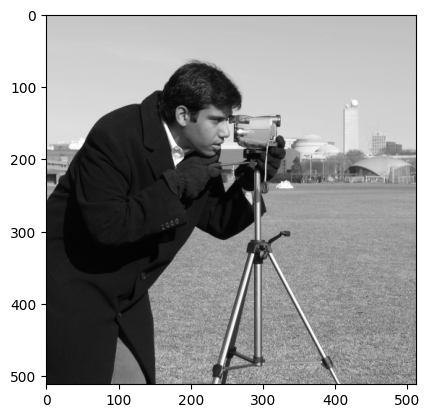

In [ ]:
camera_man = example_images.camera()

import matplotlib.pyplot as plt
plt.imshow(camera_man, cmap='gray')

We can inspect `camera_man` to see that it is a 512x512 grayscale image with gray levels 0-255 (dtype 'uint8'):

In [ ]:
camera_man.shape, camera_man.dtype

((512, 512), dtype('uint8'))

# 1. Image Transformations (10 pts)

In this section, you will implement basic image transformations, such as shifting, adjusting brightness and contrast, and correcting color balance.

**Note: The use of functions in scikit-image's `filter` module is not allowed in Section 1.** That would defeat the purpose. Please implement your filters as NumPy arrays. You can use SciPy's [convolve2d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html) function to convolve them with an image.

## 1.1 **TODO**: Write a kernel that shifts an image 1 pixel up (1 pt)

Give a NumPy array that represents a filter to shift an image upwards by 1 pixel using convolution. Demonstrate your filter on the camera man image from above.

In [ ]:
# Kernel to shift image upwards by 1 pixel
kernel = np.array([[0,1,0],
                   [0,0,0],
                   [0,0,0]])

(-0.5, 511.5, 511.5, -0.5)

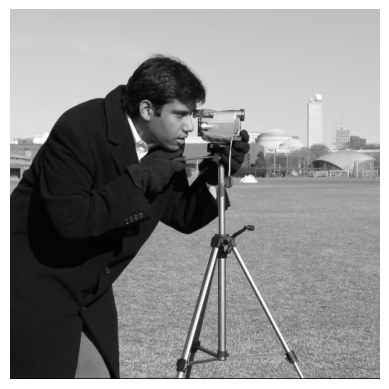

In [ ]:
from scipy.signal import convolve2d

conv_img = convolve2d(camera_man, kernel, mode='same')
plt.imshow(conv_img, cmap='gray')
plt.axis('off')

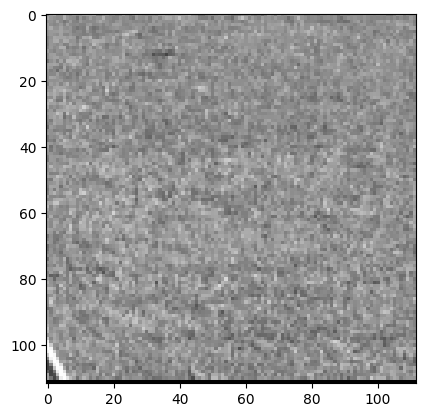

In [ ]:
# Zoom in on the bottom-right corner to show that there's a row of
# black pixels at the bottom, but no more black pixels on the right:
plt.imshow(conv_img[400:, 400:], cmap='gray')

## 1.2 **TODO**: Shift an image 2 pixels up & 2 pixels to the left (2 pts)

How would you write a kernel that shifts an image both up and to the left? This time, we want to shift the image 2 pixels up and 2 pixels to the left.

In [ ]:
# Kernel to shift image both 2 pixels up and 2 pixels to the left
kernel = np.array([[1,0,0,0,0],
                   [0,0,0,0,0],
                   [0,0,0,0,0],
                   [0,0,0,0,0],
                   [0,0,0,0,0]])

(-0.5, 511.5, 511.5, -0.5)

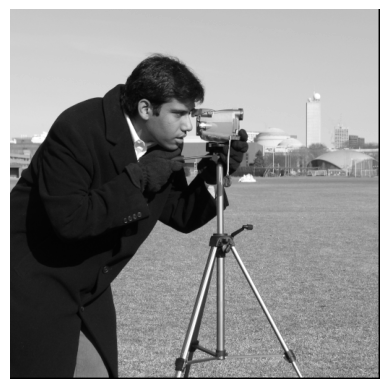

In [ ]:
conv_img = convolve2d(camera_man, kernel, mode='same')
plt.imshow(conv_img, cmap='gray')
plt.axis('off')

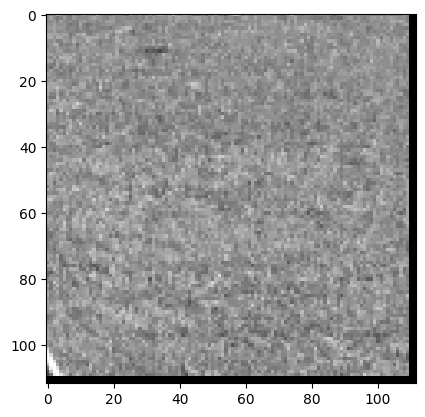

In [ ]:
# Zoom in on the bottom-right corner to show that there's now
# a 2px-wide black border:
plt.imshow(conv_img[400:, 400:], cmap='gray')

## 1.3 **TODO**: Brightness adjustment (2 pts)

Adjust the brightness of the camera man image by adding a constant `c` to each pixel value. Make sure the gray levels stay within the valid range.

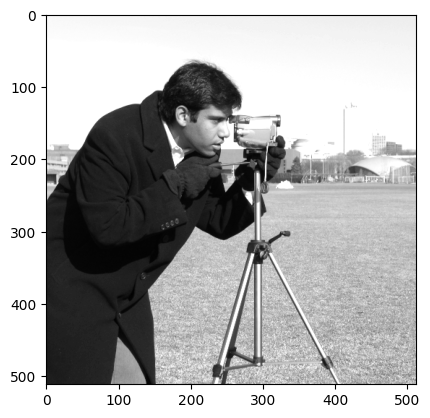

In [ ]:
c = 50
bright_image = example_images.camera()

# Nested for loop to iterate through every pixel in the image and add the brightness constant
for row in range(bright_image.shape[0]):
  for column in range(bright_image.shape[1]):
    new_pixel_value = bright_image[row][column] + c

    # Clipping the pixel values (making sure the values don't exceed 255)
    if (new_pixel_value > 255):
      bright_image[row][column] = 255

    else:
      bright_image[row][column] = new_pixel_value

plt.imshow(bright_image, cmap='gray')

## 1.4 **TODO**: Contrast adjustment (2 pts)

Reduce the contrast of the camera man image by a factor of 2.

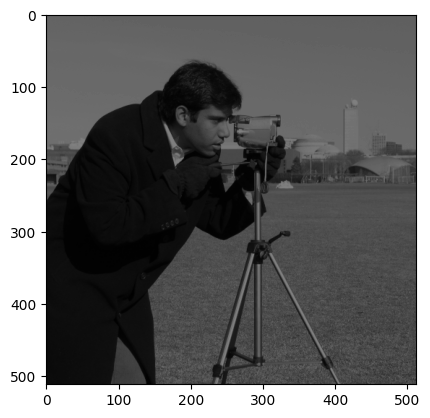

In [ ]:
reduced_contrast_image = example_images.camera()

# Dividing pixel intensities by 2 and clipping the values
reduced_contrast_image = reduced_contrast_image / 2.0
reduced_contrast_image = np.clip(reduced_contrast_image, 0, 255).astype(np.uint8)

plt.imshow(reduced_contrast_image, cmap='gray', vmin=0, vmax=255)

## 1.5 **TODO**: Color (white) balance (3 pts)

White balance is an essential step in image processing to correct color casts in an image, ensuring that colors appear as natural as possible. When an image has an incorrect white balance, white areas of the image might appear tinted with a certain color (e.g., a blueish or yellowish cast).

Why does this happen? Different lighting conditions (daylight, tungsten, fluorescent lights, etc.) affect how colors appear to the camera. For example, an image taken under fluorescent lights may have a blue tint, while one taken under tungsten lights may have a yellow tint.

Goal: Adjust the white balance to neutralize these tints, so that white objects in the scene appear truly white, which in turn makes all the colors look more natural.

To correct the white balance of an image, one common approach is to normalize the intensity values of the red, green, and blue channels. The idea is to ensure that the mean (or maximum) values of the RGB channels are balanced, so that white areas of the image contain equal amounts of red, green, and blue.

Since the camera man image is grayscale image, here we'll use another color image.

Use the following code to load the astronaut image

`astronaut = example_images.astronaut()`

Demonstrate your code on the astronaut image, displaying it "before" and "after" white balance correction.

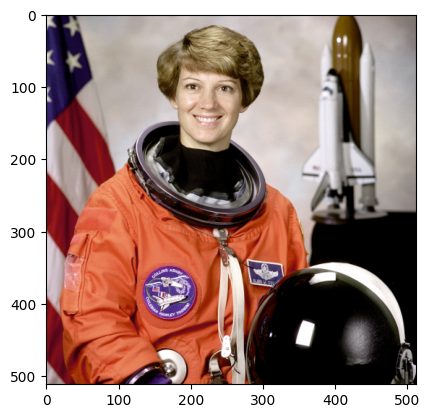

In [ ]:
astronaut = example_images.astronaut()

plt.imshow(astronaut)

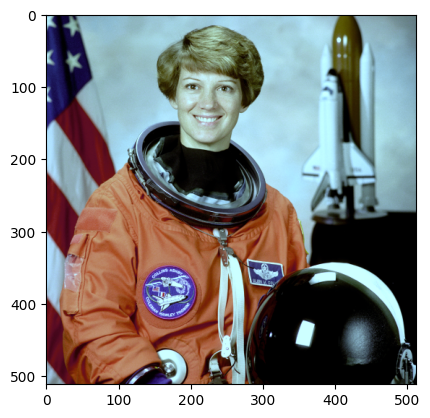

In [ ]:
astronaut_float = astronaut.astype(np.float64)

# Finding the means for all three color channels
mean_r = np.mean(astronaut_float[:, :, 0])
mean_g = np.mean(astronaut_float[:, :, 1])
mean_b = np.mean(astronaut_float[:, :, 2])

# Averaging the mean color channel values for the average gray value
average_gray = (mean_r + mean_g + mean_b) / 3

# Finding the scaling factor for each color channel
scale_r = average_gray / mean_r
scale_g = average_gray / mean_g
scale_b = average_gray / mean_b

# Multiplying pixel values by their respective scaling factors (by color channel)
astronaut_float[:, :, 0] *= scale_r
astronaut_float[:, :, 1] *= scale_g
astronaut_float[:, :, 2] *= scale_b

# Clipping pixel values
astronaut_balanced = np.clip(astronaut_float, 0, 255).astype(np.uint8)

plt.imshow(astronaut_balanced)

# 2. Image Filters (10 pts)

In this section, we want to implement our own image filters.

**Note: The use of functions in scikit-image's `filter` module is not allowed in Section 2.** Again, that would defeat the purpose. Please implement your filters as NumPy arrays. You can use SciPy's [convolve2d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html) function to convolve them with an image.

*Hint: If you need, you can use ` * ` or `np.multiply` for element-wise multiplicaton of two NumPy arrays. Matrix multiplication can be achieved with the `@` operator.*

## 2.1 **TODO**: Sobel filter (5 pts)

Implement your own Sobel filter using the following steps:

1. Write a Sobel filter that detects horizontal edges in the image
2. Write a Sobel filter that detects vertical edges in the image
3. Put the two directional derivatives together to calculate edge magnitude. The result should look qualitatively similar to [`skimage.filters.sobel`](https://scikit-image.org/docs/0.3/api/scikits.image.filter.html#sobel).

Text(0.5, 0.98, 'Implementing the Sobel filter')

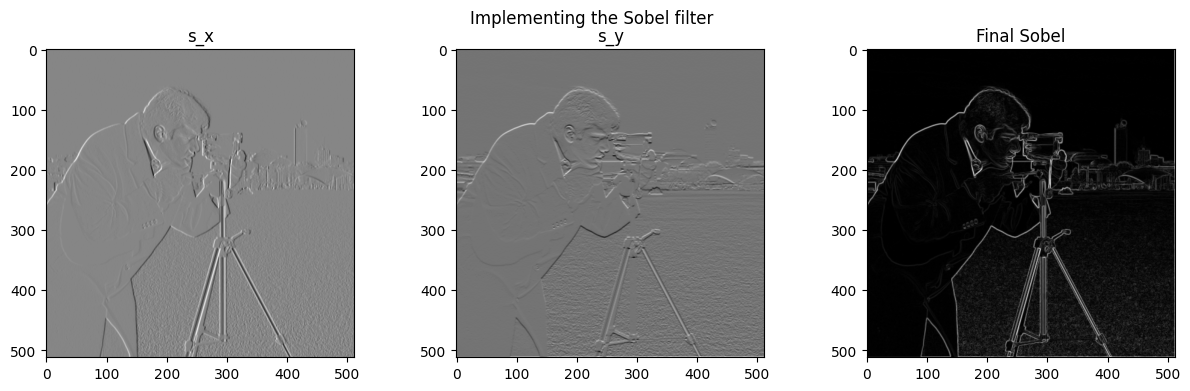

In [ ]:
# Sobel filter for detecting vertical edges
x_kernel = np.array([[-1,0,1],
                     [-2,0,2],
                     [-1,0,1]])

# Sobel filter for detecting horizontal edges
y_kernel = np.array([[-1,-2,-1],
                     [0,0,0],
                     [1,2,1]])

sobel_x = convolve2d(camera_man, x_kernel, mode='same')
sobel_y = convolve2d(camera_man, y_kernel, mode='same')

# Finding magnitude of s_x and s_y
sobel_final = np.sqrt(sobel_x**2 + sobel_y**2)

# Plotting s_x, s_y, and the final Sobel
fig, axes = plt.subplots(ncols=3, figsize=(15, 4))
sobel_images = [sobel_x, sobel_y, sobel_final]
sobel_titles = ['s_x', 's_y', 'Final Sobel']
for ax, sobel, title in zip(axes, sobel_images, sobel_titles):
    ax.imshow(sobel, cmap='gray')
    ax.set_title(title)
fig.suptitle('Implementing the Sobel filter')

You can compare your result to the one returned by scikit-image.

However, your result will likely be different from the official implementation, because:
- we are operating on ubit images, they are operating on float images
- their filter might use the opposite sign
- they might also normalize the image in an interesting way

But your result should qualitatively look the same as this:

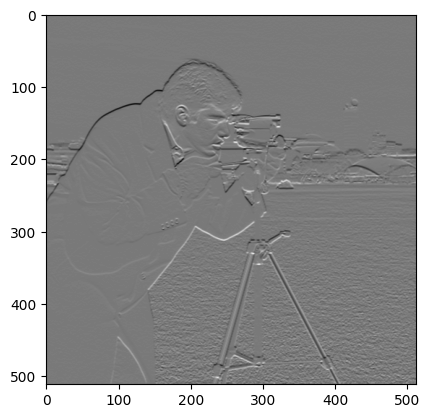

In [ ]:
from skimage.filters import sobel_h
plt.imshow(sobel_h(camera_man), cmap='gray')

In [ ]:
...

Ellipsis

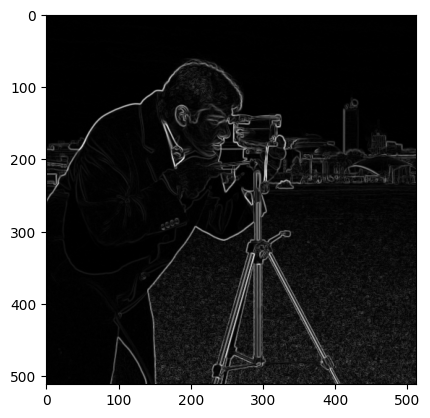

In [ ]:
# Compare (qualitatively) to the skimage solution:
from skimage.filters import sobel
plt.imshow(sobel(camera_man), cmap='gray')

## 2.2 **TODO**: Sharpening filter (5 pts)

Implement a sharpening filter by combining the original camera man image with its Gaussian-blurred version.

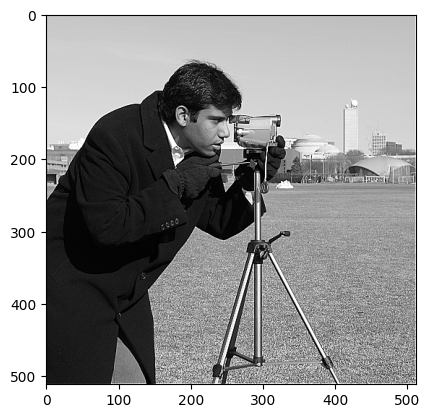

In [ ]:
from skimage.filters import gaussian

# Applying the following sharpening formula: (original image) * (scaling kernel - scaled Gaussian filter)

# Kernel to scale the original pixel intensities by 4
original_filter = np.array([[0.0,0.0,0.0],
                            [0.0,4.0,0.0],
                            [0.0,0.0,0.0]])

# Kernel for the Gaussian filter (scaled by 3)
gaussian_filter = np.array([[1.0,2.0,1.0],
                            [2.0,4.0,2.0],
                            [1.0,2.0,1.0]])

gaussian_filter *= (0.1875)

camera_man_float = example_images.camera().astype(np.float64)
convolve_matrix = original_filter - gaussian_filter
camera_man_sharpened = convolve2d(camera_man_float, convolve_matrix, mode='same')
camera_man_sharpened = np.clip(camera_man_sharpened, 0, 255)

plt.imshow(camera_man_sharpened, cmap='gray')

# 3. Canny Edge Detection (10 pts)

Now we want to implement Canny edge detection using `skimage.feature.canny`. You might find [this example](https://scikit-image.org/docs/stable/auto_examples/edges/plot_canny.html) helpful.

Scikit-Image does most of the job for you, but you need to finetune the Canny parameters.

In [ ]:
...

Ellipsis

## 3.1 **TODO**: Experiment with the standard deviation of the Gaussian filter (3 pts)

Let's apply Canny to the image of the camera man that we used above.
The first parameter we want to focus on is `sigma`. How does the output change with varying `sigma` values, and why?

Which `sigma` value would you choose for this particular image and why?

Text(0.5, 0.98, 'Canny edge detection for different sigma values')

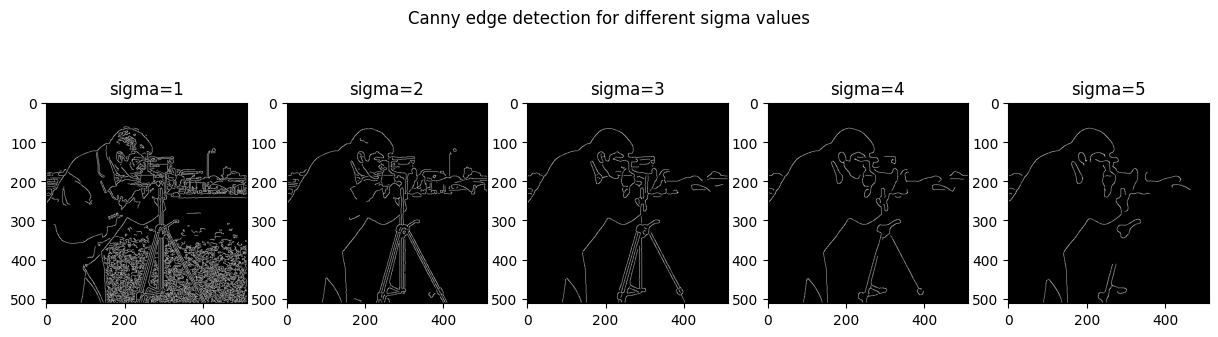

In [ ]:
from skimage.feature import canny

camera_man_canny = example_images.camera()

# Canny edge detection for sigma values 1 to 5
canny_1 = canny(camera_man_canny, sigma=1)
canny_2 = canny(camera_man_canny, sigma=2)
canny_3 = canny(camera_man_canny, sigma=3)
canny_4 = canny(camera_man_canny, sigma=4)
canny_5 = canny(camera_man_canny, sigma=5)

canny_images = [canny_1, canny_2, canny_3, canny_4, canny_5]

# Plotting Canny edge detection images for each sigma value
fig, axes = plt.subplots(ncols=5, figsize=(15, 4))
canny_titles = ['sigma=1', 'sigma=2', 'sigma=3', 'sigma=4', 'sigma=5']
for ax, canny, title in zip(axes, canny_images, canny_titles):
    ax.imshow(canny, cmap='gray')
    ax.set_title(title)
fig.suptitle('Canny edge detection for different sigma values')

---

As the values of sigma increase, the number of detected edges decreases. For instance, with a sigma value of 1, the Canny edge detector returns an image with multiple defined edges. However, with a sigma value of 5, there are far fewer edges. I would choose a sigma value of 3, as it shows the basic outlines of the key features in the image.

---

How does increasing $\sigma$ affect the sharpness of the edges? At what point do the edges become too smoothed to be useful?

---

Increasing $\sigma$ causes the edges to become less sharp. A lot of the main features get lost. After $\sigma = 3$, I think the edges become too smoothed to be useful, as it's hard to point out certain features of the photo.

---

## 3.2 **TODO**: Experiment with the thresholds (3 pts)

The other two parameters are `high_threshold` and `low_threshold`, which define the upper and lower bound for the hysteresis thresholding, respectively. How does the result change as you vary these two parameters, and why?

Which values would you choose for this particular image and why?

Text(0.5, 0.98, 'Hysteresis thresholding for different threshold values')

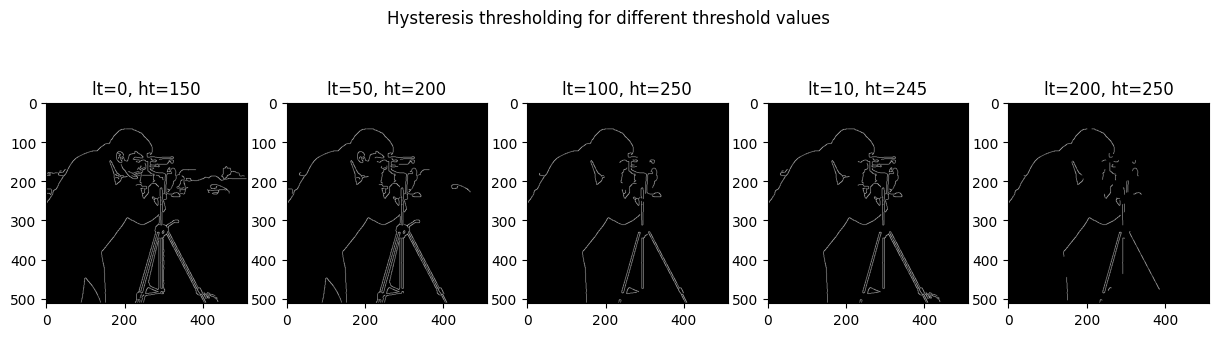

In [ ]:
from skimage.feature import canny

# Hysteresis thresholding - same threshold range
hysteresis_1 = canny(camera_man_canny, sigma=1.5, low_threshold=0, high_threshold=150)
hysteresis_2 = canny(camera_man_canny, sigma=1.5, low_threshold=50, high_threshold=200)
hysteresis_3 = canny(camera_man_canny, sigma=1.5, low_threshold=100, high_threshold=250)

# Hysteresis thresholding - differing threshold range
hysteresis_4 = canny(camera_man_canny, sigma=1.5, low_threshold=10, high_threshold=245)
hysteresis_5 = canny(camera_man_canny, sigma=1.5, low_threshold=200, high_threshold=250)

hysteresis_images = [hysteresis_1, hysteresis_2, hysteresis_3, hysteresis_4, hysteresis_5]

# Plotting hysteresis thresholding images (where sigma=1.5)
fig, axes = plt.subplots(ncols=5, figsize=(15, 4))
hysteresis_titles = ['lt=0, ht=150', 'lt=50, ht=200', 'lt=100, ht=250', 'lt=10, ht=245', 'lt=200, ht=250']
for ax, hysteresis, title in zip(axes, hysteresis_images, hysteresis_titles):
    ax.imshow(hysteresis, cmap='gray')
    ax.set_title(title)
fig.suptitle('Hysteresis thresholding for different threshold values')

---

Increasing the high threshold reduces the number of strong edges, meaning features like the building and the camera get lost. However, decreasing the low threshold allows for finer edges, such as the edges of facial features and the camera stand details.

As I increased both the low and high thresholds (maintaining a gap of 150 between the two thresholds), there are less edges (the features in the background of the image are lost). For this particular image, I would choose a low threshold of 0 and a high threshold of 150, as the edges of the main features are defined.

---

What happens to the edges when the thresholds are set too close together or too far apart? How does this affect the quality of edge detection?

---

When the thresholds are set too far apart, the main edges of key features are defined, but some features (like the background) are lost. However, when the thresholds are set too close together, a lot of the edges are lost (only the camera man and his camera stand are outlined, while the camera and background are lost). Setting the thresholds closer together reduces the quality of edge detection.

---

## 3.3 **TODO**: Compare Canny and Sobel (4 pts)

Using the parameter values you identified above, compare the edges detected by Canny and Sobel. How do they differ? Consider factors like edge smoothness, noise, and the types of edges each method highlights.

---

Canny: Canny edge detection is better for detecting finer edges. For instance, for the camera man image, Canny can detect the smaller details, such as facial features. It is smoother than the edges detected with Sobel, but sometimes misses out on the bigger features while picking up on the smaller features (depending on the threshold and sigma values).

Sobel: Sobel edge detection is better for detecting the coarser, strong edges. This method is good for illustrating the basic outline of an image. Compared to Canny, the edges are more rough, but it's easy to see the key features of an image.

---


Which algorithm performs better for detecting finer edges? When might you prefer one method over the other?

---

Canny is better for detecting finer edges. Given that it is more complex than Sobel, it's able to pick up on the smaller details in images. When you want to detect the edges in a simple image (one without multiple small features), you should use Sobel, as it is less complex and outlines the main features. However, when you have an image with multiple features and details, you should use Canny, as it can detect more edges.

---

# 4. Marr-Hildreth Algorithm (20 pts)

Lastly, we want to follow up on the edge detection lecture and implement the [Marr-Hildreth edge algorithm](https://en.wikipedia.org/wiki/Marr%E2%80%93Hildreth_algorithm) from scratch. Although this name did not come up in class, it is based on filters and operators that should be familiar to you.

The algorithm can be divided into two steps:
- Convolving the image (at different scales) with the Laplacian of a Gaussian.
- Searching for zero crossings in the filtered image to obtain the edges.

You can again use the camera man image to demonstrate your solution.

## 4.1 **TODO:** Gaussian pyramid (6 pts)

Using only [NumPy](https://numpy.org), write a function that returns a Gaussian kernel of a given width, $\sigma$:

$$ g(x,y; \sigma) = \exp \bigg(-\frac{(x-x_0)^2+(y-y_0)^2}{2 \sigma^2} \bigg) $$

Here, the Gaussian function is centered on $(x_0, y_0)$.

Note that the kernel size should equal at least 3 sigma of the continuous Gaussian function, which means that the filter size is not a constant and should increase with sigma.
Make sure that the filter size is always an odd number (round up if necessary).

It's also a good idea to normalize the kernel so that all filter elements add up to 1. This way, you don't artficially change the range of grayscale values in the image.

In [ ]:
import numpy as np

def gaussian_kernel(sigma, truncate=3):
    """Gaussian kernel

    Parameters
    ----------
    sigma : float
        Standard deviation of the Gaussian
    truncate : float
        Truncate the kernel at `truncate` standard deviations.
        Default: 3 standard deviations

    Returns
    -------
    gaussian_kernel : np.ndarray
        A (truncate*sigma, truncat*sigma) 2D NumPy array with the Gaussian
        kernel. Number of pixels are rounded up to the nearest odd integer.
    """

    # Finding kernel size (truncate*sigma)
    kernel_size = int(np.ceil(truncate*sigma))
    sum = 0

    # Centering at (kernel_size / 2, kernel_size / 2)
    x0 = kernel_size / 2
    y0 = kernel_size / 2

    # Ensuring that kernel_size is odd
    if (kernel_size % 2 == 0):
      kernel_size += 1

    gaussian_kernel = np.zeros((kernel_size, kernel_size))

    for x in range(kernel_size):
      for y in range(kernel_size):
        # Updating each value in the Gaussian kernel
        input = ((x - x0)**2 + (y - y0)**2)/(2 * (sigma**2))
        sum += input
        gaussian_kernel[x][y] = np.exp(-input)

    # Normalizing Gaussian kernel
    gaussian_kernel /= sum

    return gaussian_kernel

Now use your Gaussian function to create five different Gaussian filters with sigma 3, 6, 12, 24, and 48 pixels.

Plot the filters using [Matplotlib](https://matplotlib.org). You may want to check out the [`subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) command.

Text(0.5, 0.98, 'Gaussian kernels')

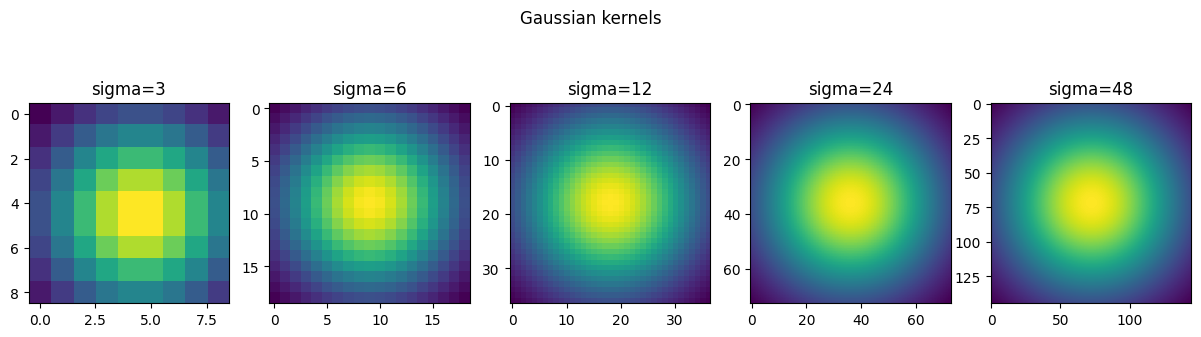

In [ ]:
sigmas = 3, 6, 12, 24, 48
gaussian_masks = []

# Plotting each Gaussian kernel (at different sigmas)
fig, axes = plt.subplots(ncols=len(sigmas), figsize=(15, 4))
for ax, sigma in zip(axes, sigmas):
    kernel = gaussian_kernel(sigma)
    ax.imshow(kernel)
    gaussian_masks.append(kernel)
    ax.set_title(f'sigma={sigma}')
fig.suptitle('Gaussian kernels')

Then apply each filter to the camera-man image and plot the result. For this, you can use [`scipy.signal.convolve2d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html).
- Make sure to use mode='same' in `convolve2d` to make the resulting image the same size as the original.
- To avoid border effects, we need to choose a boundary method other than the default - 'wrap' works well, but others are also possible.
If you used 'fill' (default), you should see ringing artifacts (https://en.wikipedia.org/wiki/Ringing_artifacts) that might mess with your Laplacian operator below (especially at larger `sigma`s).

Text(0.5, 0.98, 'Convolution of camera man with Gaussian kernels')

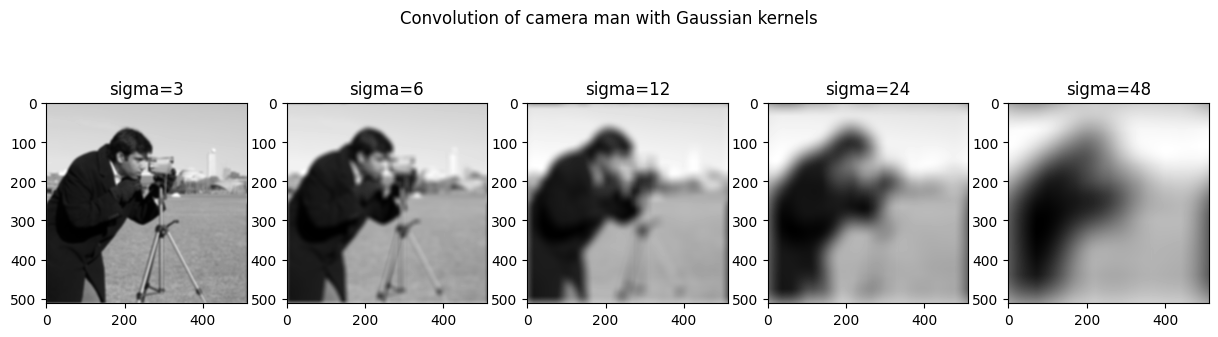

In [ ]:
sigmas = 3, 6, 12, 24, 48
image = example_images.camera()

# Plotting each convolution of camera man with Gaussian kernels
fig, axes = plt.subplots(ncols=len(sigmas), figsize=(15, 4))
for ax, sigma in zip(axes, sigmas):
    convolve_image = convolve2d(image, gaussian_kernel(sigma), mode='same', boundary='wrap')
    ax.imshow(convolve_image, cmap='gray')
    ax.set_title(f'sigma={sigma}')
fig.suptitle('Convolution of camera man with Gaussian kernels')

## 4.2 **TODO:** Laplacian of a Gaussian (3 pts)

Convolve the pyramid of the Gaussian masks with a Laplacian operator mask to generate the Laplacian of a Gaussian (LoG, aka "Mexican Hat").

Then convolve the 5 LoG operators with your input image (so you should get 5 filtered images out):

Text(0.5, 0.98, 'Convolution of 5 LoG operators')

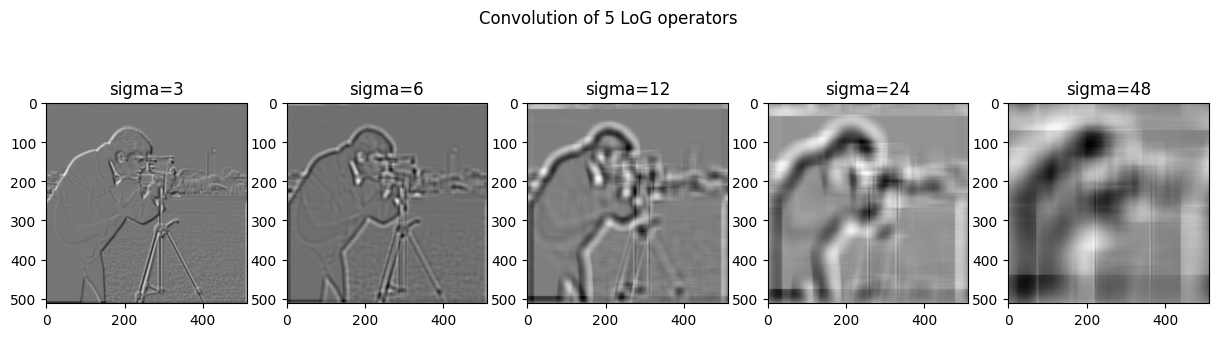

In [ ]:
# Approximation of the Laplacian kernel
laplacian_kernel = np.array([[0,-1,0],
                             [-1,4,-1],
                             [0,-1,0]])

laplacian_masks = []
filtered_images = []

for gmask in gaussian_masks:
  # Convolving Gaussian masks with Laplacian kernel
  convolve_image = convolve2d(gmask, laplacian_kernel, mode='same', boundary='wrap')
  laplacian_masks.append(convolve_image)

# Plotting the convolution of the camera man with the Laplacian masks
fig, axes = plt.subplots(ncols=len(sigmas), figsize=(15, 4))
for ax, sigma, lmask in zip(axes, sigmas, laplacian_masks):
    convolve_image = convolve2d(camera_man, lmask, mode='same', boundary='wrap')
    filtered_images.append(convolve_image)
    ax.imshow(convolve_image, cmap='gray')
    ax.set_title(f'sigma={sigma}')
fig.suptitle('Convolution of 5 LoG operators')

Make sure to use boundary='symm' or 'wrap' to reduce the occurrence of ringing artifacts. Even if you used one of these boundary settings, the Laplacian might amplify outlier values found near the image boundaries. As a result, you may still see some artifacts (especially at larger sigma values).

(In my case, sigma=24 and sigma=48 look different, but that's mostly because `ax.imshow` automatically adjusts the grayscale range, so if you change the command to something like `ax.imshow(img_laplace[-1], cmap='gray', vmin=1e-3, vmax=1e3)` the two should look pretty much the same.)

## 4.3 **TODO:** Zero crossings (7 pts)

Finally, we need to detect the zero-crossings (not zeros!) in the filtered images. These will serve as our edge points.

A zero crossing at pixel `p` implies that the signs of at least two opposite neighboring pixels are different. There are four cases to test: left/right, up/down, and the two diagonals (up-left/down-right and up-right/down-left).

A pixel `p` is considered an edge pixel if any of the following conditions are met:
- the sign of the left/right neighbors is opposite AND the difference between their gray levels is greater than `threshold`
- the sign of the up/down neighbors is opposite AND the difference between their gray levels is greater than `threshold`
- the sign of the up-left/down-right neighbors is opposite AND the difference between their gray levels is greater than `threshold`
- the sign of the up-right/down-left neighbors is opposite AND the difference between their gray levels is greater than `threshold`

It is easiest to put all this logic in a function. The function should accept a filtered image `img` and a threshold `threshold`.
It should return an array of zeros and ones (same size as input `img`), where all pixels that are considered edges have a 1, and all other pixels are 0.

In [ ]:
def zero_crossings(img, threshold=0):
    """Find the zero crossings in an image

    Parameters
    ----------
    img : np.ndarray
        A 2D NumPy array for which zero crossings should be found
    threshold : float, optional
        Minimum difference of neighboring gray values required to consider
        the zero crossing an edge

    Returns
    -------
    zero_cross : np.ndarray
        An image of the same size as `img` with zero crossings=1, all other
        pixels=0
    """
    zero_cross = np.zeros_like(img)
    mean = 0

    # Finding the mean of the pixel values
    for i in range(img.shape[0]):
      for j in range(img.shape[1]):
        mean += img[i][j]

    mean /= img.size

    # Subtracting the mean from each pixel value
    for i in range(img.shape[0]):
      for j in range(img.shape[1]):
        img[i][j] -= mean

    for row in range(1, img.shape[0] - 1):
      for col in range(1, img.shape[1] - 1):
        # The sign of the left/right neighbors is opposite AND the difference between their gray levels is greater than threshold
        if ((img[row][col-1] > 0 and img[row][col+1] < 0) or (img[row][col-1] < 0 and img[row][col+1] > 0)):
          if (np.abs(img[row][col-1] - img[row][col+1]) > threshold):
            zero_cross[row][col] = 1

        # The sign of the up/down neighbors is opposite AND the difference between their gray levels is greater than threshold
        if ((img[row-1][col] > 0 and img[row+1][col] < 0) or (img[row-1][col] < 0 and img[row+1][col] > 0)):
          if (np.abs(img[row-1][col] - img[row+1][col]) > threshold):
            zero_cross[row][col] = 1

        # The sign of the up-left/down-right neighbors is opposite AND the difference between their gray levels is greater than threshold
        if ((img[row-1][col-1] > 0 and img[row+1][col+1] < 0) or (img[row-1][col-1] < 0 and img[row+1][col+1] > 0)):
          if (np.abs(img[row-1][col-1] - img[row+1][col+1]) > threshold):
            zero_cross[row][col] = 1

        # The sign of the up-right/down-left neighbors is opposite AND the difference between their gray levels is greater than threshold
        if ((img[row+1][col-1] > 0 and img[row-1][col+1] < 0) or (img[row+1][col-1] < 0 and img[row-1][col+1] > 0)):
          if (np.abs(img[row+1][col-1] - img[row-1][col+1]) > threshold):
            zero_cross[row][col] = 1

    return zero_cross

Then apply the function to the 5 different filtered images to get 5 binary edge maps back.

Experiment with different values of `threshold` to get a good result.
The result should look something like the Canny edge detector: white lines on a black image. You can also google for example of images of the Marr-Hildreth edge detector.

You should see that the edges in the 5 filtered images depend on the sigma of the Gaussian kernel.

Text(0.5, 0.98, 'Binary edge maps')

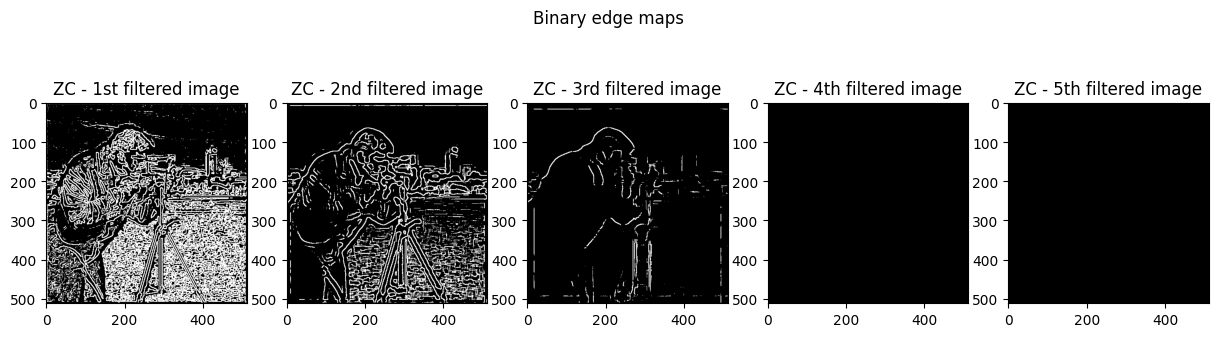

In [ ]:
# Zero crossings for each each filtered image
zero_crossings_1 = zero_crossings(filtered_images[0], threshold=0.06)
zero_crossings_2 = zero_crossings(filtered_images[1], threshold=0.06)
zero_crossings_3 = zero_crossings(filtered_images[2], threshold=0.06)
zero_crossings_4 = zero_crossings(filtered_images[3], threshold=0.06)
zero_crossings_5 = zero_crossings(filtered_images[4], threshold=0.06)

zc_images = [zero_crossings_1, zero_crossings_2, zero_crossings_3, zero_crossings_4, zero_crossings_5]
zc_titles = ['ZC - 1st filtered image', 'ZC - 2nd filtered image', 'ZC - 3rd filtered image', 'ZC - 4th filtered image', 'ZC - 5th filtered image']

# Plotting each zero crossing
fig, axes = plt.subplots(ncols=5, figsize=(15, 4))
for ax, zc, title in zip(axes, zc_images, zc_titles):
    ax.imshow(zc, cmap='gray')
    ax.set_title(title)
fig.suptitle('Binary edge maps')

## 4.4 **TODO:** Role of sigma and threshold (4 pts)

Now that you have experimented with different values for `sigma` and `threshold`, what are their respective roles? i.e.
- How does the result change with increasing `sigma`? What do you have to consider when choosing a `sigma` value?
- How does the result change with increasing `threshold`? What do you have to consider when choosing a `threshold` value?

---

1. By increasing sigma, the image gets blurrier. Because of this, the edges are less pronounced, as it's harder to outline the features (the edges of smaller features get lost). When choosing the sigma value, you should consider the level of noise in the image, the scale of the features, and the level of smoothing required.
2. Changing the threshold controls the number of edges outlined. For instance, if you have a larger threshold window, more edges are in included. However, increasing both the low and the high threshold will cause less edges to be included. When choosing a threshold value, you should consider the balance between the number of strong edges and the amount of noise (figuring out what feature edges you want to be outlined).

---

# 5. Extra Credit (5 pts)

In this extra credit section, you will experiment with adding noise to images and applying different denoising techniques to clean the noisy images. You will then reflect on which denoising method works best in different situations.

## 5.1 **TODO**: Gaussian and salt-and-pepper noise

First, implement two different types of noise (without the help of `skimage.util`):
- Gaussian noise, also known as normal noise, is typically caused by electronic noise in sensors or cameras. It is characterized by a random distribution of pixel intensities, drawn from a normal distribution with Gaussian width `sigma`.
- Salt-and-pepper noise consists of randomly occuring white an black pixels, like "static" on a TV screen. It is usually caused by sharp, sudden disturbances in image signals. Implement this by flipping a fraction `frac` of pixels to either black or white.

For each noise type, write a function that takes as input an image as well as the noise-specific parameters, and outputs a noisy image. Try it on the camera man image.


In [ ]:
def gaussian_noise(image, mean=0, sigma=10):
  noise = np.random.normal(mean, sigma, camera_man.shape)

  # Adding Gaussian noise and clipping pixel values
  noisy_image = image + noise
  noisy_image = np.clip(noisy_image, 0, 255)

  return noisy_image


def salt_and_pepper_noise(image, frac=0.05):
  noisy_image = np.copy(image)

  # Half of the fraction of pixels should be white, half of the fraction of pixels should be black
  num_salt = int(np.ceil((frac * image.size) / 2))
  num_pepper = int(np.ceil((frac * image.size) / 2))

  # Choosing random coordinates to turn into white pixels
  for i in range(num_salt):
    x = np.random.randint(low=0, high=image.shape[0]-1)
    y = np.random.randint(low=0, high=image.shape[1]-1)
    noisy_image[x][y] = 255

  # Choosing random coordinates to turn into black pixels
  for i in range(num_pepper):
    x = np.random.randint(low=0, high=image.shape[0]-1)
    y = np.random.randint(low=0, high=image.shape[1]-1)
    noisy_image[x][y] = 0

  return noisy_image

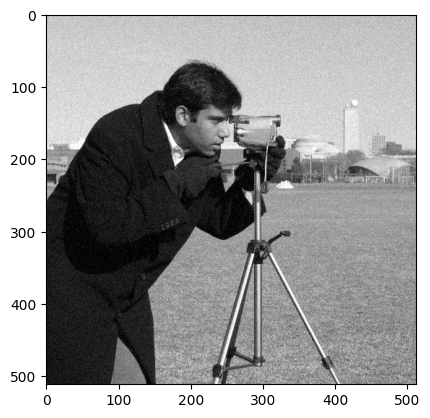

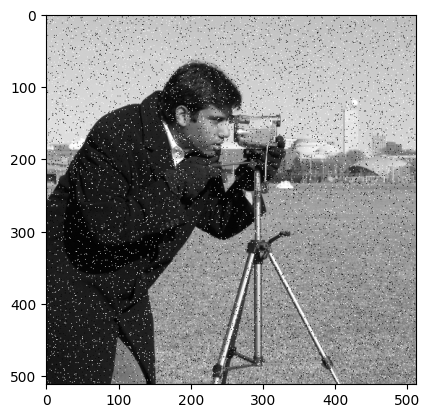

In [ ]:
# Plotting camera man with Gaussian noise
camera_man_gn = gaussian_noise(camera_man)
plt.imshow(camera_man_gn, cmap='gray')
plt.show()

# Plotting camera man with salt and pepper noise
camera_man_spn = salt_and_pepper_noise(camera_man)
plt.imshow(camera_man_spn, cmap='gray')
plt.show()

## 5.2 **TODO**: Denoising with a median filter

Now that you've applied noise to the image, you will clean it using a median filter. Median filtering works by replacing each pixel value with the median of the intensities in a neighborhood around the pixel. You may use `skimage.filters.median` for this.

Apply the median filter to noisy versions of the camera man images using the two noise types from above. Experiment with different noise settings. Plot the noisy and clean images side by side.

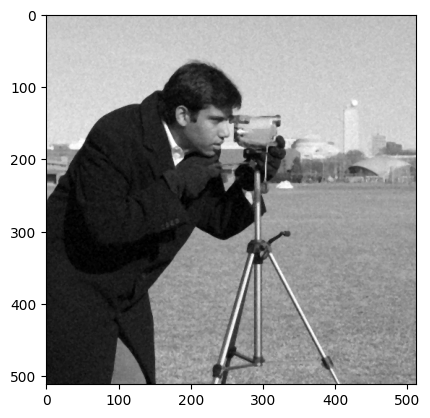

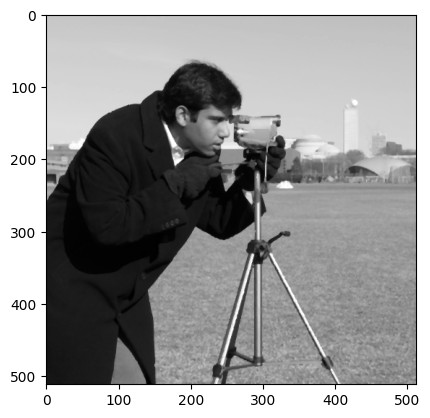

In [ ]:
from skimage.filters import median

# Applying the median filter on the noisy images
clean_gn = median(camera_man_gn)
clean_spn = median(camera_man_spn)

# Plotting denoised camera man with Gaussian noise
plt.imshow(clean_gn, cmap='gray')
plt.show()

# Plotting denoised camera man with salt and pepper noise
plt.imshow(clean_spn, cmap='gray')
plt.show()

How effective is the median filter in removing salt-and-pepper noise? Why do you think it works so well (or so poorly)?

---

The median filter is quite effective in removing salt-and-pepper noise. I think it works well because opposed to the Gaussian noise, the salt-and-pepper noise retains most of the original pixel values. Therefore, when we replace the pixel values with the median of the neighboring values, we get pixels that are closer to the original pixel values. With Gaussian noise, the noise is more "smoothed out," meaning it's hard to recover the original pixel values with the median filter.

---

How did the median filter perform on the image with Gaussian noise? Is median filtering the best option for this type of noise? If not, what might work better?

---

As mentioned in my previous answer, the median filter didn't remove the Gaussian noise very well. I don't think the median filtering is the best option for this type of noise, as it is comparatively patchy (the noise is still somewhat visible). Since the noise is more "smoothed out" across the pixels, a mean filter might be a better option for removing Gaussian noise. The mean filter smooths the intensity variations by averaging the neighboring pixel values. The random fluctuations (around the true pixel values) from the Gaussian noise are likely to be reduced when averaged with neighboring pixels. However, averaging these values can blur edges and fine details.

---